In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_palette("tab10")

In [2]:
df = pd.read_csv("likelihood.csv")

In [3]:
df.shape

(270, 22)

In [4]:
rts = df.groupby("pid").rt.mean().reset_index()
rts = rts[rts.rt < np.quantile(rts.rt, 0.10)]
print(rts)

df = df[~df.pid.isin(rts.pid)]

                         pid           rt
16  63f94e6a56d57031c54cb24c  6142.333333
21  663a5c3ef84d9c74ea3c07a1  4832.222222
23  6650e2ba4eceb07b4da4a7cd  6282.555556


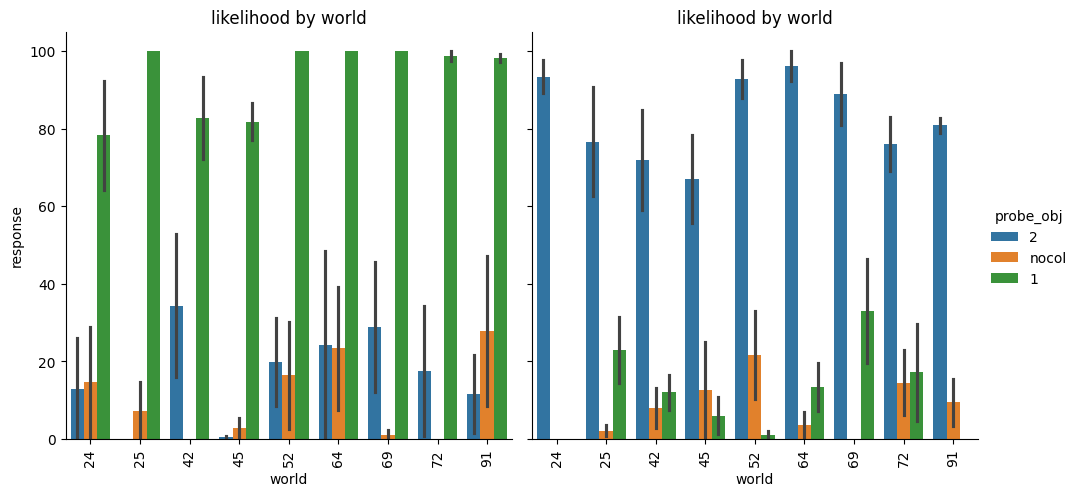

In [4]:
p = sns.catplot(df, x="world", y="response", hue="probe_obj", col="worldtype", palette="tab10", kind="bar", errorbar="se", order=sorted(df.world.unique()))
p.set_xticklabels(rotation=90)
p.set(title="likelihood by world")
# p.set_xticklabels(labels=sorted(df.world.unique()), rotation=90)
# 0004, 0001, 0048

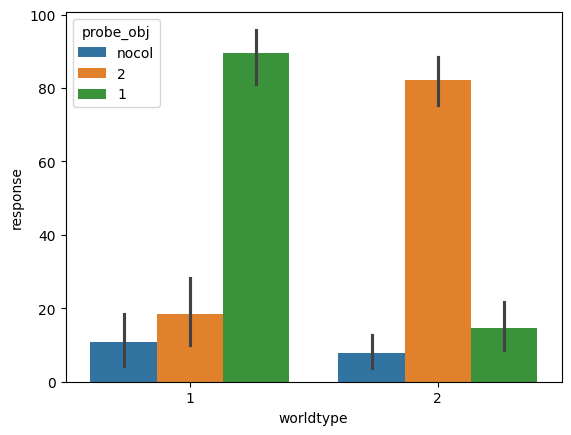

In [5]:
tmp = df[~df.world.isin(["lh_ll_unlink_plinko_0004", "lh_ll_unlink_plinko_0001", "lh_ll_unlink_plinko_0048"])]
p = sns.barplot(df, x="worldtype", y="response", hue="probe_obj", errorbar="ci", palette="tab10")

In [6]:
df

,trial,rt,response,world,img1_1,img1_2,img2_1,img2_2,recording1_1,recording1_2,...,sim_x_result1,sim_x_result2,filler,probe_obj,probe_shift_id,worldtype,teleporter_entry_color_idx,teleporter_entry_color,pid,img
0,0,14804,3,25,assets/targets/0025/img1_1.png,assets/targets/0025/img1_2.png,assets/targets/0025/img2_1.png,assets/targets/0025/img2_2.png,assets/targets/0025/recording1_1.mp4,assets/targets/0025/recording1_2.mp4,...,275.751786,548.084970,False,1,1,2,1,blue,6650e2ba4eceb07b4da4a7cd,assets/targets/0025/base_1_1_red.jpg
1,1,5354,0,72,assets/targets/0072/img1_1.png,assets/targets/0072/img1_2.png,assets/targets/0072/img2_1.png,assets/targets/0072/img2_2.png,assets/targets/0072/recording1_1.mp4,assets/targets/0072/recording1_2.mp4,...,263.498769,480.292700,False,nocol,2,1,1,blue,6650e2ba4eceb07b4da4a7cd,assets/targets/0072/base_nocol_2_red.jpg
2,2,5039,0,52,assets/targets/0052/img1_1.png,assets/targets/0052/img1_2.png,assets/targets/0052/img2_1.png,assets/targets/0052/img2_2.png,assets/targets/0052/recording1_1.mp4,assets/targets/0052/recording1_2.mp4,...,570.256717,231.913427,False,nocol,2,1,1,blue,6650e2ba4eceb07b4da4a7cd,assets/targets/0052/base_nocol_2_red.jpg
3,3,5430,100,64,assets/targets/0064/img1_1.png,assets/targets/0064/img1_2.png,assets/targets/0064/img2_1.png,assets/targets/0064/img2_2.png,assets/targets/0064/recording1_1.mp4,assets/targets/0064/recording1_2.mp4,...,572.435126,233.990061,False,2,2,2,1,blue,6650e2ba4eceb07b4da4a7cd,assets/targets/0064/base_2_1_red.jpg
4,4,9178,0,24,assets/targets/0024/img1_1.png,assets/targets/0024/img1_2.png,assets/targets/0024/img2_1.png,assets/targets/0024/img2_2.png,assets/targets/0024/recording1_1.mp4,assets/targets/0024/recording1_2.mp4,...,392.505473,36.174058,False,2,2,1,1,blue,6650e2ba4eceb07b4da4a7cd,assets/targets/0024/base_2_2_red.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,4,5860,0,45,assets/targets/0045/img1_1.png,assets/targets/0045/img1_2.png,assets/targets/0045/img2_1.png,assets/targets/0045/img2_2.png,assets/targets/0045/recording1_1.mp4,assets/targets/0045/recording1_2.mp4,...,436.655905,257.959506,False,nocol,1,1,0,brown,667c73ba70ed69bf1a17c1ce,assets/targets/0045/base_nocol_1_red.jpg
266,5,6523,0,91,assets/targets/0091/img1_1.png,assets/targets/0091/img1_2.png,assets/targets/0091/img2_1.png,assets/targets/0091/img2_2.png,assets/targets/0091/recording1_1.mp4,assets/targets/0091/recording1_2.mp4,...,360.263292,232.431351,False,nocol,1,2,0,brown,667c73ba70ed69bf1a17c1ce,assets/targets/0091/base_nocol_2_red.jpg
267,6,9811,100,64,assets/targets/0064/img1_1.png,assets/targets/0064/img1_2.png,assets/targets/0064/img2_1.png,assets/targets/0064/img2_2.png,assets/targets/0064/recording1_1.mp4,assets/targets/0064/recording1_2.mp4,...,572.435126,233.990061,False,2,2,2,0,brown,667c73ba70ed69bf1a17c1ce,assets/targets/0064/base_2_2_red.jpg
268,7,3635,100,25,assets/targets/0025/img1_1.png,assets/targets/0025/img1_2.png,assets/targets/0025/img2_1.png,assets/targets/0025/img2_2.png,assets/targets/0025/recording1_1.mp4,assets/targets/0025/recording1_2.mp4,...,275.751786,548.084970,False,2,1,2,0,brown,667c73ba70ed69bf1a17c1ce,assets/targets/0025/base_2_2_red.jpg


In [19]:
# split half correlation of collision likelihood
def split_likelihood(df):
    idx = np.random.choice(df.index, size=df.shape[0] // 2, replace=False)
    df1 = df.loc[idx, ["probe_obj", "worldtype", "world", "response"]]
    df2 = df.loc[~df.index.isin(idx), ["probe_obj", "world", "worldtype", "response"]]
    df1 = df1.groupby(["probe_obj", "world", "worldtype"])["response"].mean().reset_index()
    df2 = df2.groupby(["probe_obj", "world", "worldtype"])["response"].mean().reset_index()
    merged = pd.merge(df1, df2, on=["probe_obj", "world", "worldtype"], suffixes=("_1", "_2"))
    return merged

_n = 50
split_cor = 0
for _ in range(_n):
    split_cor += split_likelihood(df)[["response_1", "response_2"]].corr().iloc[0, 1]
print(split_cor / _n)

0.8365182596657751


In [73]:
df_pilot = pd.read_csv("../pilot_bouncer_norm/likelihood.csv")

In [74]:
df_pilot.columns

Index(['trial', 'rt', 'response', 'world', 'filler', 'sim_x_result1', 'img1',
       'recording1', 'probe1_1_img0', 'probe1_1_img1', 'probe1_2_img0',
       'probe1_2_img1', 'probe2_1_img0', 'probe2_1_img1', 'probe2_2_img0',
       'probe2_2_img1', 'sim_x_result2', 'img2', 'recording2', 'worldtype',
       'pid', 'img', 'probe_obj'],
      dtype='object')

In [87]:
df1 = pd.concat([df, df_pilot], axis=0)
df1

,trial,rt,response,world,filler,sim_x_result1,img1,recording1,probe1_1_img0,probe1_1_img1,...,probe2_1_img1,probe2_2_img0,probe2_2_img1,sim_x_result2,img2,recording2,worldtype,pid,img,probe_obj
0,0,16118,50,lh_ll_unlink_plinko_0048,False,456.655811,assets/targets/lh_ll_unlink_plinko_0048/img1.jpg,assets/targets/lh_ll_unlink_plinko_0048/record...,['assets/targets/lh_ll_unlink_plinko_0048/stim...,['assets/targets/lh_ll_unlink_plinko_0048/stim...,...,['assets/targets/lh_ll_unlink_plinko_0048/stim...,['assets/targets/lh_ll_unlink_plinko_0048/stim...,['assets/targets/lh_ll_unlink_plinko_0048/stim...,26.791146,assets/targets/lh_ll_unlink_plinko_0048/img2.jpg,assets/targets/lh_ll_unlink_plinko_0048/record...,2,6129cbb730e7705df0d0fb2a,assets/targets/lh_ll_unlink_plinko_0048/normst...,1
1,1,5494,74,lh_ll_unlink_plinko_0001,False,399.867355,assets/targets/lh_ll_unlink_plinko_0001/img1.jpg,assets/targets/lh_ll_unlink_plinko_0001/record...,['assets/targets/lh_ll_unlink_plinko_0001/stim...,['assets/targets/lh_ll_unlink_plinko_0001/stim...,...,['assets/targets/lh_ll_unlink_plinko_0001/stim...,['assets/targets/lh_ll_unlink_plinko_0001/stim...,['assets/targets/lh_ll_unlink_plinko_0001/stim...,45.756470,assets/targets/lh_ll_unlink_plinko_0001/img2.jpg,assets/targets/lh_ll_unlink_plinko_0001/record...,2,6129cbb730e7705df0d0fb2a,assets/targets/lh_ll_unlink_plinko_0001/normst...,2
2,2,8051,0,lh_hl_unlink_plinko_0000,False,298.225607,assets/targets/lh_hl_unlink_plinko_0000/img1.jpg,assets/targets/lh_hl_unlink_plinko_0000/record...,['assets/targets/lh_hl_unlink_plinko_0000/stim...,['assets/targets/lh_hl_unlink_plinko_0000/stim...,...,['assets/targets/lh_hl_unlink_plinko_0000/stim...,['assets/targets/lh_hl_unlink_plinko_0000/stim...,['assets/targets/lh_hl_unlink_plinko_0000/stim...,560.181299,assets/targets/lh_hl_unlink_plinko_0000/img2.jpg,assets/targets/lh_hl_unlink_plinko_0000/record...,1,6129cbb730e7705df0d0fb2a,assets/targets/lh_hl_unlink_plinko_0000/normst...,2
3,3,3581,0,lh_ll_unlink_plinko_0036,False,77.693842,assets/targets/lh_ll_unlink_plinko_0036/img1.jpg,assets/targets/lh_ll_unlink_plinko_0036/record...,['assets/targets/lh_ll_unlink_plinko_0036/stim...,['assets/targets/lh_ll_unlink_plinko_0036/stim...,...,['assets/targets/lh_ll_unlink_plinko_0036/stim...,['assets/targets/lh_ll_unlink_plinko_0036/stim...,['assets/targets/lh_ll_unlink_plinko_0036/stim...,519.964900,assets/targets/lh_ll_unlink_plinko_0036/img2.jpg,assets/targets/lh_ll_unlink_plinko_0036/record...,2,6129cbb730e7705df0d0fb2a,assets/targets/lh_ll_unlink_plinko_0036/normst...,1
4,4,5072,96,lh_ll_unlink_plinko_0101,False,159.310984,assets/targets/lh_ll_unlink_plinko_0101/img1.jpg,assets/targets/lh_ll_unlink_plinko_0101/record...,['assets/targets/lh_ll_unlink_plinko_0101/stim...,['assets/targets/lh_ll_unlink_plinko_0101/stim...,...,['assets/targets/lh_ll_unlink_plinko_0101/stim...,['assets/targets/lh_ll_unlink_plinko_0101/stim...,['assets/targets/lh_ll_unlink_plinko_0101/stim...,548.250655,assets/targets/lh_ll_unlink_plinko_0101/img2.jpg,assets/targets/lh_ll_unlink_plinko_0101/record...,1,6129cbb730e7705df0d0fb2a,assets/targets/lh_ll_unlink_plinko_0101/normst...,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,4,27782,100,lh_ll_unlink_plinko_0007,False,532.903770,assets/targets/lh_ll_unlink_plinko_0007/img1.jpg,assets/targets/lh_ll_unlink_plinko_0007/record...,['assets/targets/lh_ll_unlink_plinko_0007/stim...,['assets/targets/lh_ll_unlink_plinko_0007/stim...,...,['assets/targets/lh_ll_unlink_plinko_0007/stim...,['assets/targets/lh_ll_unlink_plinko_0007/stim...,['assets/targets/lh_ll_unlink_plinko_0007/stim...,19.534180,assets/targets/lh_ll_unlink_plinko_0007/img2.jpg,assets/targets/lh_ll_unlink_plinko_0007/record...,2,66737ebe3fb98f796de7631d,assets/targets/lh_ll_unlink_plinko_0007/normst...,2
257,5,10526,0,lh_ll_unlink_plinko_0036,False,77.693842,assets/targets/lh_ll_unlink_plinko_0036/img1.jpg,assets/targets/lh_ll_unlink_plinko_0036

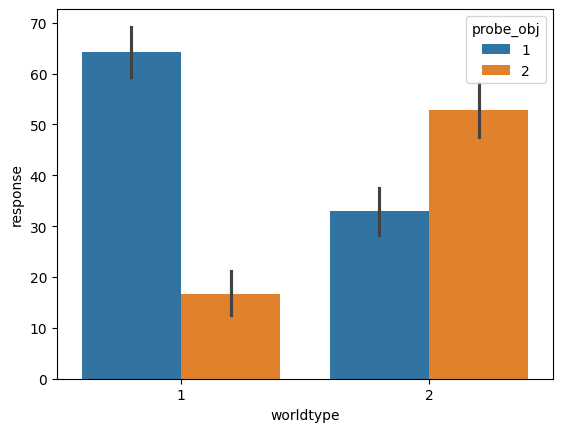

In [88]:
tmp = df1[~df1.world.isin(["lh_ll_unlink_plinko_0004", "lh_ll_unlink_plinko_0001", "lh_ll_unlink_plinko_0048"])]
p = sns.barplot(df1, x="worldtype", y="response", hue="probe_obj", errorbar="ci", palette="tab10")

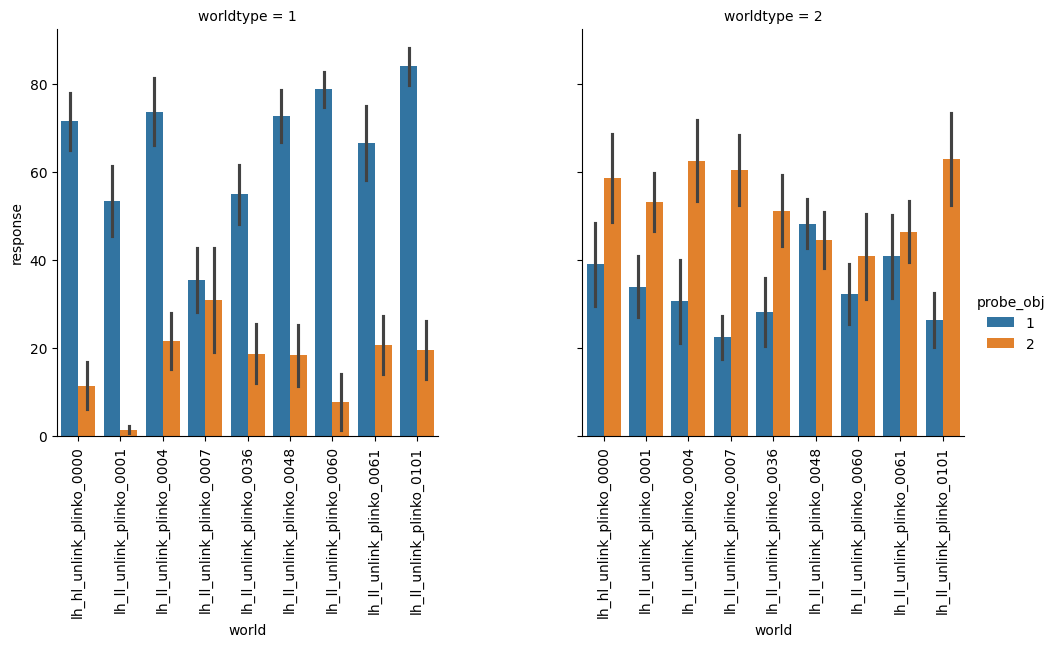

In [89]:
p = sns.catplot(df1, x="world", y="response", hue="probe_obj", col="worldtype", palette="tab10", kind="bar", errorbar="se", order=sorted(df1.world.unique()))
p.set_xticklabels(rotation=90)
# p.set_xticklabels(labels=sorted(df1.world.unique()), rotation=90)


In [90]:
df1.groupby(["worldtype", "probe_obj"]).response.mean()

worldtype  probe_obj
1          1            64.148148
           2            16.728571
2          1            32.977941
           2            52.808333
Name: response, dtype: float64

In [91]:
print(df1.shape)
print(df.shape)

(531, 23)
(270, 23)


In [27]:
df["consistent"] = df["probe_obj"] == df["worldtype"]

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_43291/2165417101.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["consistent"] = df["probe_obj"] == df["worldtype"]


In [28]:
df.consistent

1      False
2       True
5      False
6      False
7      False
       ...  
254     True
256     True
257     True
258    False
260     True
Name: consistent, Length: 156, dtype: bool

In [33]:
# p = sns.catplot(df, x="consistent", y="response", hue="worldtype", row="pid", palette="tab10", errorbar="se", kind="point")
# p._legend.remove()

In [30]:
df.columns

Index(['trial', 'rt', 'response', 'world', 'filler', 'sim_x_result1', 'img1',
       'recording1', 'probe1_1_img0', 'probe1_1_img1', 'probe1_2_img0',
       'probe1_2_img1', 'probe2_1_img0', 'probe2_1_img1', 'probe2_2_img0',
       'probe2_2_img1', 'sim_x_result2', 'img2', 'recording2', 'worldtype',
       'pid', 'img', 'probe_obj', 'consistent'],
      dtype='object')

In [26]:
pred = pd.read_csv("predictions.csv")

In [27]:
from ast import literal_eval

pred.world

0      lh_ll_unlink_plinko_0002
1      lh_hl_unlink_plinko_0007
2      lh_ll_unlink_plinko_0022
3      lh_ll_unlink_plinko_0012
4      lh_ll_unlink_plinko_0013
                 ...           
805    lh_ll_unlink_plinko_0101
806    lh_hl_unlink_plinko_0002
807    lh_ll_unlink_plinko_0038
808    lh_ll_unlink_plinko_0002
809    lh_ll_unlink_plinko_0036
Name: world, Length: 810, dtype: object

In [28]:
pred.columns

Index(['trial', 'filler', 'world', 'worldType', 'pid', 'true_x', 'img',
       'clickPositions', 'clickTimes', 'totalTime', 'points'],
      dtype='object')

In [44]:
def mae(x):
    ps = literal_eval(x.clickPositions)
    return np.mean([np.abs(p - x.true_x) for p in ps])

# pred.groupby("world")[["clickPositions", "true_x"]].agg(mse)
pred["mae"] = pred.apply(mae, axis=1)

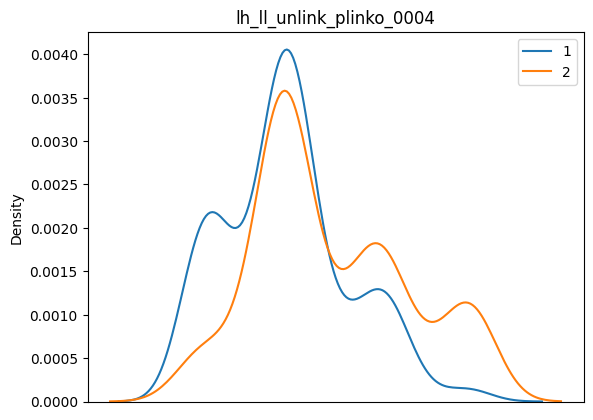

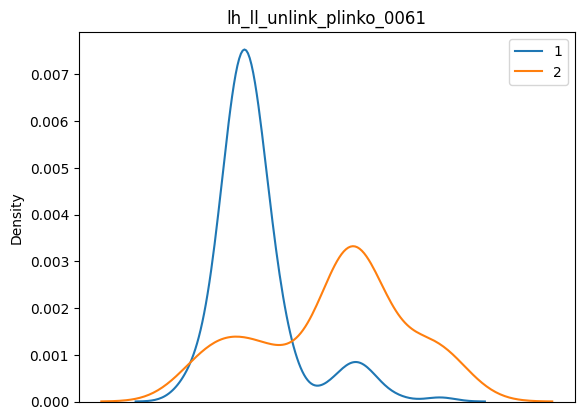

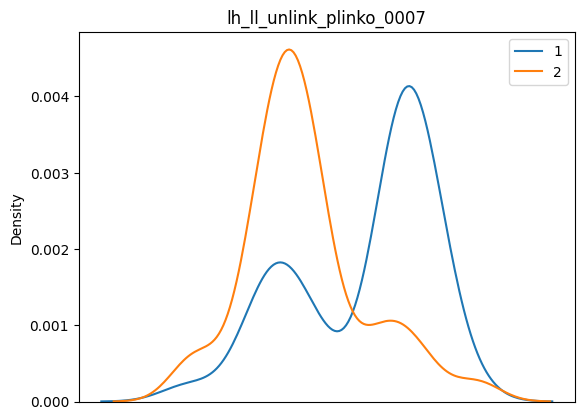

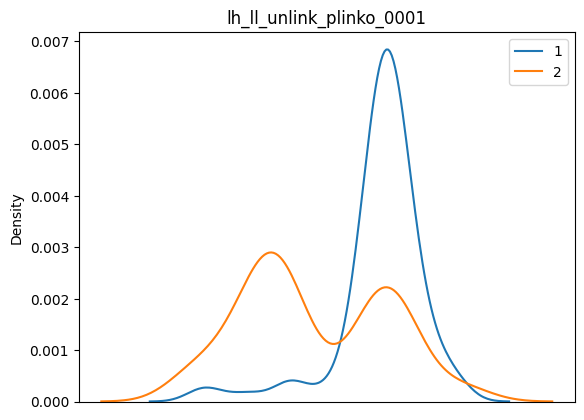

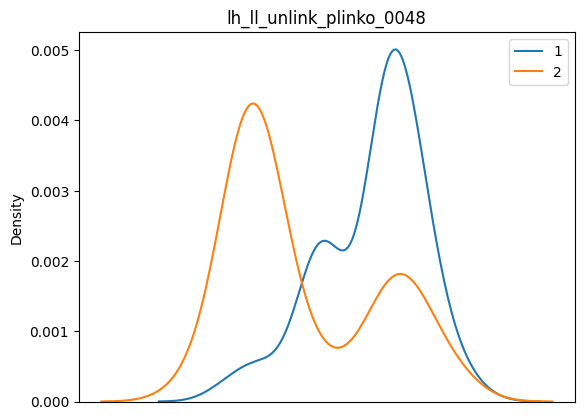

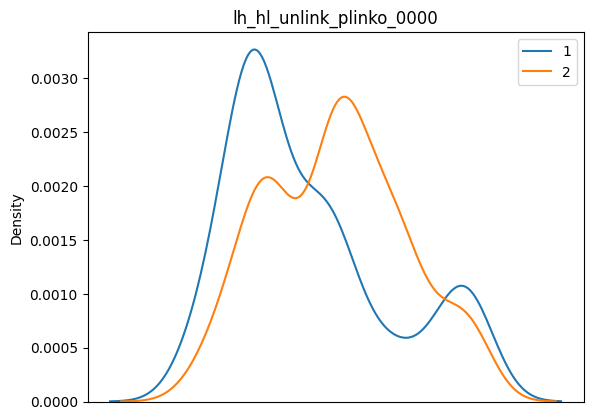

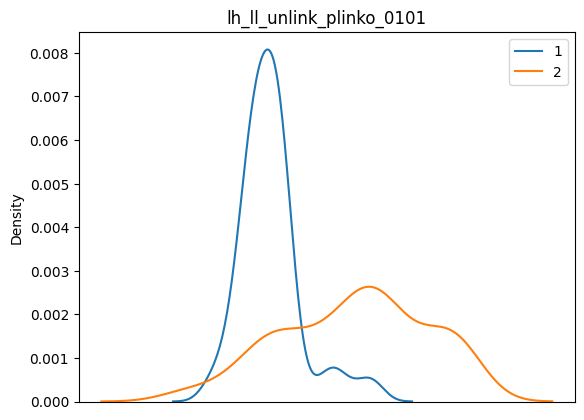

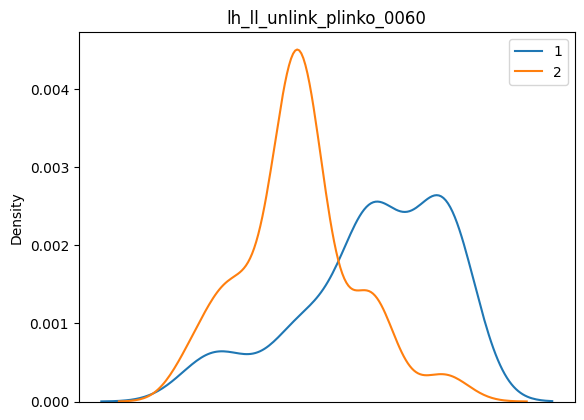

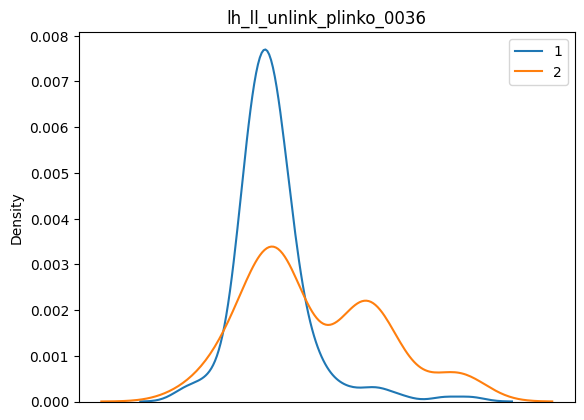

In [37]:
for world in pred[pred.filler == False].world.unique():
    plt.figure()
    for worldtype in [1, 2]:
        tmp = []
        for idx, row in pred[(pred.world == world) & (pred.worldType == worldtype)].iterrows():
            tmp.append(literal_eval(row["clickPositions"]))
        tmp = np.array(tmp)
        # plt.subplot(1, 2, worldtype)
        sns.kdeplot(tmp.ravel(), label=f"{worldtype}")
        plt.xticks([])
        plt.title(f"{world}")
        plt.legend()

In [38]:
pred1 = pd.read_csv("../exp_bouncer_norm/predictions.csv")

In [45]:
pred1["mae"] = pred1.apply(mae, axis=1)

In [47]:
pd.merge(
    pred.groupby(["world", "worldType"]).mae.mean().reset_index(),
    pred1.groupby(["world", "worldType"]).mae.mean().reset_index(),
    on=["world", "worldType"],
    suffixes=("_ll", "_bn"),
)
#.pipe(sns.relplot, x="mse_ll", y="mse_bn", hue="world", palette="tab10")

,world,worldType,mae_ll,mae_bn
0,lh_hl_unlink_plinko_0000,1,136.606814,136.606814
1,lh_hl_unlink_plinko_0000,2,215.769083,215.769083
2,lh_hl_unlink_plinko_0001,1,174.777238,174.777238
3,lh_hl_unlink_plinko_0001,2,188.525642,188.525642
4,lh_hl_unlink_plinko_0002,1,197.309147,197.309147
5,lh_hl_unlink_plinko_0002,2,132.999767,132.999767
6,lh_hl_unlink_plinko_0003,1,107.993645,107.993645
7,lh_hl_unlink_plinko_0003,2,80.351488,80.351488
8,lh_hl_unlink_plinko_0007,1,107.401237,107.401237
9,lh_hl_unlink_plinko_0007,2,77.885292,77.885292


In [49]:
pred.groupby(["world", "worldType"]).mae.mean().reset_index(),

(                       world  worldType         mae
 0   lh_hl_unlink_plinko_0000          1  136.606814
 1   lh_hl_unlink_plinko_0000          2  215.769083
 2   lh_hl_unlink_plinko_0001          1  174.777238
 3   lh_hl_unlink_plinko_0001          2  188.525642
 4   lh_hl_unlink_plinko_0002          1  197.309147
 5   lh_hl_unlink_plinko_0002          2  132.999767
 6   lh_hl_unlink_plinko_0003          1  107.993645
 7   lh_hl_unlink_plinko_0003          2   80.351488
 8   lh_hl_unlink_plinko_0007          1  107.401237
 9   lh_hl_unlink_plinko_0007          2   77.885292
 10  lh_hl_unlink_plinko_0008          1  120.787885
 11  lh_hl_unlink_plinko_0008          2   64.313495
 12  lh_ll_unlink_plinko_0001          1   58.426296
 13  lh_ll_unlink_plinko_0001          2  208.984791
 14  lh_ll_unlink_plinko_0002          1  126.052040
 15  lh_ll_unlink_plinko_0002          2  154.169239
 16  lh_ll_unlink_plinko_0004          1  113.341327
 17  lh_ll_unlink_plinko_0004          2  124.